In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('data/student-por.csv')

In [5]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [6]:
df.isna().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

THERE ARE NO MISSING VALUES IN DATASET


In [7]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values in the dataset


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [9]:
df.nunique()

school         2
sex            2
age            8
address        2
famsize        2
Pstatus        2
Medu           5
Fedu           5
Mjob           5
Fjob           5
reason         4
guardian       3
traveltime     4
studytime      4
failures       4
schoolsup      2
famsup         2
paid           2
activities     2
nursery        2
higher         2
internet       2
romantic       2
famrel         5
freetime       5
goout          5
Dalc           5
Walc           5
health         5
absences      24
G1            17
G2            16
G3            17
dtype: int64

In [10]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [11]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 16 numerical features : ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

We have 17 categorical features : ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


Feature Engineering


In [12]:
X = df.drop("G3", axis=1)
y = df["G3"]

In [13]:
df["grade_improvement"] = df["G2"] - df["G1"]

In [14]:
df["absence_level"] = pd.cut(
    df["absences"],
    bins=[-1, 0, 5, 10, 20, 100],
    labels=["None", "Low", "Moderate", "High", "Very High"]
)

In [15]:
df["alcohol_score"] = df["Dalc"] + df["Walc"]

In [16]:
df["avg_alcohol"] = (df["Dalc"] + df["Walc"]) / 2

In [17]:
df["social_activity_score"] = df["freetime"] + df["goout"]

In [18]:
df["parent_education_avg"] = (df["Medu"] + df["Fedu"]) / 2

In [19]:
df["parent_education_gap"] = abs(df["Medu"] - df["Fedu"])

In [20]:
df["academic_risk"] = df["failures"] + df["absences"]

In [21]:
from sklearn.preprocessing import OneHotEncoder
OneHotEncoder(handle_unknown="ignore")

OneHotEncoder(handle_unknown='ignore')

In [22]:
binary_columns = [
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic"
]

for col in binary_columns:
    df[col] = df[col].map({"yes": 1, "no": 0})

In [23]:
df["absence_level"] = pd.cut(
    df["absences"],
    bins=[-1, 0, 5, 10, 20, 100],
    labels=["No Absence", "Low", "Moderate", "High", "Very High"]
)

In [24]:
print(df["absence_level"].value_counts())

absence_level
No Absence    244
Low           234
Moderate      122
High           41
Very High       8
Name: count, dtype: int64


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [26]:
from sklearn.preprocessing import StandardScaler
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [27]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [28]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot_encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
print(X_train.shape)
print(X_test.shape)

(519, 32)
(130, 32)


In [32]:
X = df.drop("G3", axis=1)
y = df["G3"]

In [33]:
print("G3 in X:", "G3" in X.columns)
print("G3 in y:", "G3" in y.name)

G3 in X: False
G3 in y: True


In [34]:
numeric_features = [
    feature for feature in X.columns
    if X[feature].dtype != 'O'
]

categorical_features = [
    feature for feature in X.columns
    if X[feature].dtype == 'O'
]

In [35]:
print(numeric_features)
print(categorical_features)

['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'grade_improvement', 'absence_level', 'alcohol_score', 'avg_alcohol', 'social_activity_score', 'parent_education_avg', 'parent_education_gap', 'academic_risk']
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian']


In [36]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot_encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
X = df.drop("G3", axis=1)
y = df["G3"]

In [40]:
from pandas.api.types import is_numeric_dtype

numeric_features = [
    col for col in X.columns
    if is_numeric_dtype(X[col])
]

categorical_features = [
    col for col in X.columns
    if not is_numeric_dtype(X[col])
]

In [41]:
print("Numerical:")
print(numeric_features)

print("\nCategorical:")
print(categorical_features)

Numerical:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'grade_improvement', 'alcohol_score', 'avg_alcohol', 'social_activity_score', 'parent_education_avg', 'parent_education_gap', 'academic_risk']

Categorical:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'absence_level']


In [42]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot_encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
X_train_transformed = preprocessor.fit_transform(X_train)

X_test_transformed = preprocessor.transform(X_test)

In [46]:
print("G3 in X:", "G3" in X.columns)
print("G3 in numeric_features:", "G3" in numeric_features)
print("G3 in categorical_features:", "G3" in categorical_features)

G3 in X: False
G3 in numeric_features: False
G3 in categorical_features: False


In [47]:
for col in X.columns:
    if X[col].dtype != "object":
        print(col, X[col].unique())

age [18 17 15 16 19 22 20 21]
Medu [4 1 3 2 0]
Fedu [4 1 2 3 0]
traveltime [2 1 3 4]
studytime [2 3 1 4]
failures [0 3 1 2]
schoolsup [1 0]
famsup [0 1]
paid [0 1]
activities [0 1]
nursery [1 0]
higher [1 0]
internet [0 1]
romantic [0 1]
famrel [4 5 3 1 2]
freetime [3 2 4 1 5]
goout [4 3 2 1 5]
Dalc [1 2 5 3 4]
Walc [1 3 2 4 5]
health [3 5 1 2 4]
absences [ 4  2  6  0 10  8 16 14  1 12 24 22 32 30 21 15  9 18 26  7 11  5 13  3]
G1 [ 0  9 12 14 11 13 10 15 17  8 16 18  7  6  5  4 19]
G2 [11 13 14 12 16 17  8 10 15  9  7  6 18 19  0  5]
grade_improvement [11  2  1  0 -1  3 -2 -3  4 -7  5 -4 -9 -5 -8]
absence_level ['Low', 'Moderate', 'No Absence', 'High', 'Very High']
Categories (5, object): ['No Absence' < 'Low' < 'Moderate' < 'High' < 'Very High']
alcohol_score [ 2  5  3  4  6 10  7  8  9]
avg_alcohol [1.  2.5 1.5 2.  3.  5.  3.5 4.  4.5]
social_activity_score [ 7  6  5  4  8 10  9  3  2]
parent_education_avg [4.  1.  3.  3.5 2.  2.5 1.5 0.5 0. ]
parent_education_gap [0 2 1 4 3]
academ

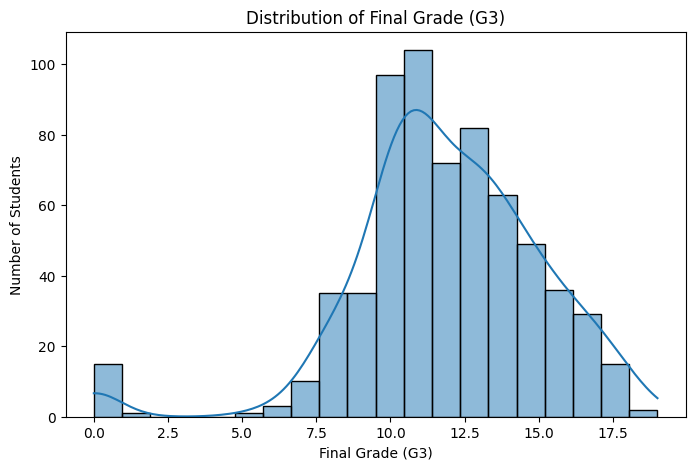

In [48]:
# Check the distribution of the target variable G3

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="G3", bins=20, kde=True)

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.show()

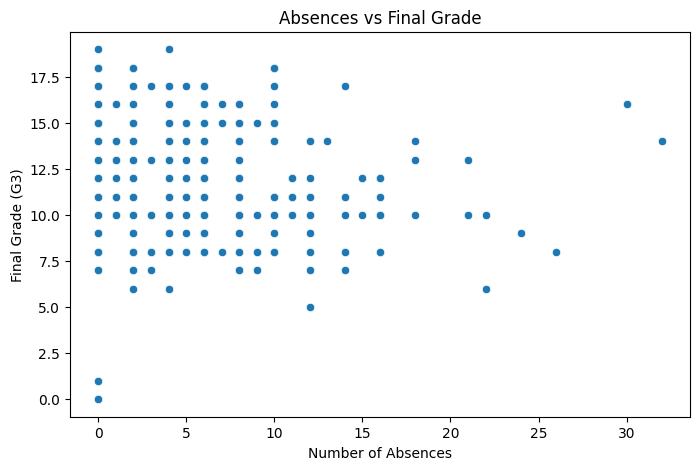

In [49]:
# Relationship between absences and final grade

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="absences", y="G3")

plt.title("Absences vs Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")

plt.show()

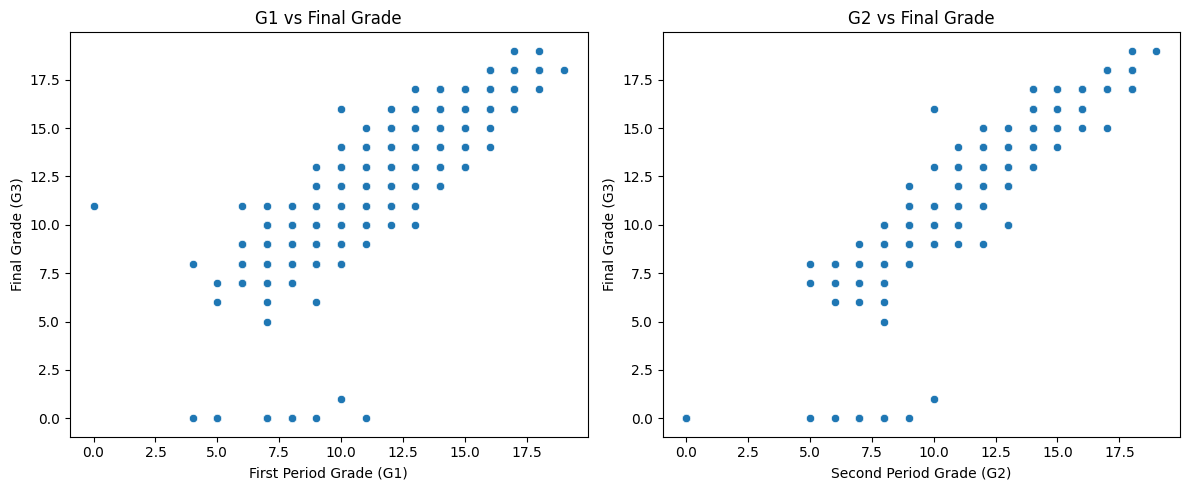

In [50]:
# Relationship between previous grades and final grade

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df, x="G1", y="G3", ax=axes[0])
axes[0].set_title("G1 vs Final Grade")
axes[0].set_xlabel("First Period Grade (G1)")
axes[0].set_ylabel("Final Grade (G3)")

sns.scatterplot(data=df, x="G2", y="G3", ax=axes[1])
axes[1].set_title("G2 vs Final Grade")
axes[1].set_xlabel("Second Period Grade (G2)")
axes[1].set_ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

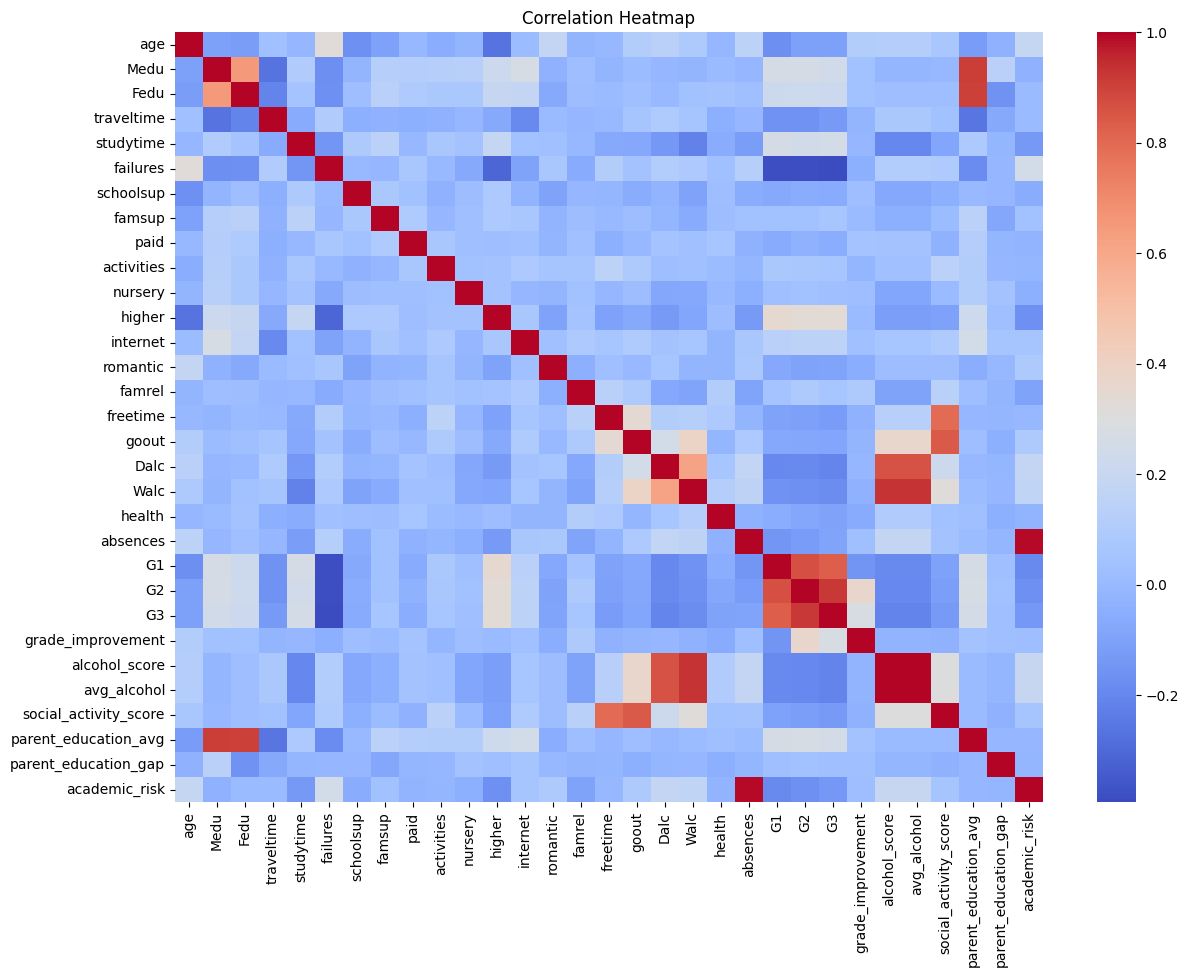

In [51]:
# Correlation between numerical variables

plt.figure(figsize=(14, 10))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=False,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [52]:
# Create Pass/Fail target

df["pass_fail"] = np.where(df["G3"] >= 10, 1, 0)

df["pass_fail"].value_counts()

pass_fail
1    549
0    100
Name: count, dtype: int64